# Donations ML Pipeline by Chapter (Textbook-Aligned)

This notebook builds a machine learning pipeline focused on `donations.csv`, organized by textbook chapters.

## Coverage Map
- Chapters 0-1: Problem framing + CRISP-DM setup
- Chapters 2-4: Data loading, structure, and reproducible I/O
- Chapters 6-8: Univariate + bivariate EDA and cleaning decisions
- Chapters 9-12: Regression baselines + decision tree regression
- Chapters 13-16: Classification, ensembles, model selection, feature selection
- Chapters 17-18: Deployment artifact + monitoring blueprint
- Chapters 19-20: Time trends + clustering
- Chapters 21-22: Text processing + topic extraction from notes
- Chapter 27: Final recommendations and action checklist

Notes:
- Focus is strictly `../datasets/donations.csv`.
- Some chapters in the textbook are modality-specific (image/recommender) and are not applicable to this dataset.

In [2]:
# Chapters 0-4: Setup, business framing, and reproducible loading
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    silhouette_score,
)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

data_path = Path("../datasets/donations.csv")
df = pd.read_csv(data_path)

print(f"Loaded rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded rows: 420
Columns: ['donation_id', 'supporter_id', 'donation_type', 'donation_date', 'is_recurring', 'campaign_name', 'channel_source', 'currency_code', 'amount', 'estimated_value', 'impact_unit', 'notes', 'referral_post_id']


,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,1074.65,1074.65,pesos,Campaign support,NaN
3,4,33,Monetary,2023-09-11,False,NaN,PartnerReferral,PHP,1230.56,1230.56,pesos,In support of safehouse operations,NaN
4,5,24,InKind,2023-11-08,True,GivingTuesday,SocialMedia,NaN,NaN,1177.41,items,In support of safehouse operations,421.0


In [3]:
# Chapters 0-1: Problem statement + success metrics
problem_statement = {
    "objective": "Predict donation value and recurring likelihood to support campaign/channel decisions.",
    "regression_target": "estimated_value",
    "classification_target": "is_recurring",
    "primary_business_kpi": "Increase total monthly estimated donation value",
    "secondary_kpi": "Increase recurring donation rate",
}

print(json.dumps(problem_statement, indent=2))

# Quick structural audit (Chapters 2-3)
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
})
summary

{
  "objective": "Predict donation value and recurring likelihood to support campaign/channel decisions.",
  "regression_target": "estimated_value",
  "classification_target": "is_recurring",
  "primary_business_kpi": "Increase total monthly estimated donation value",
  "secondary_kpi": "Increase recurring donation rate"
}


,dtype,missing_count,missing_pct,n_unique
donation_id,int64,0,0.00,420
supporter_id,int64,0,0.00,59
donation_type,object,0,0.00,5
donation_date,object,0,0.00,350
is_recurring,bool,0,0.00,2
campaign_name,object,275,65.48,4
channel_source,object,0,0.00,5
currency_code,object,186,44.29,1
amount,float64,186,44.29,224
estimated_value,float64,0,0.00,390


Donation type distribution:
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

Recurring distribution:
is_recurring
True     211
False    209
Name: count, dtype: int64


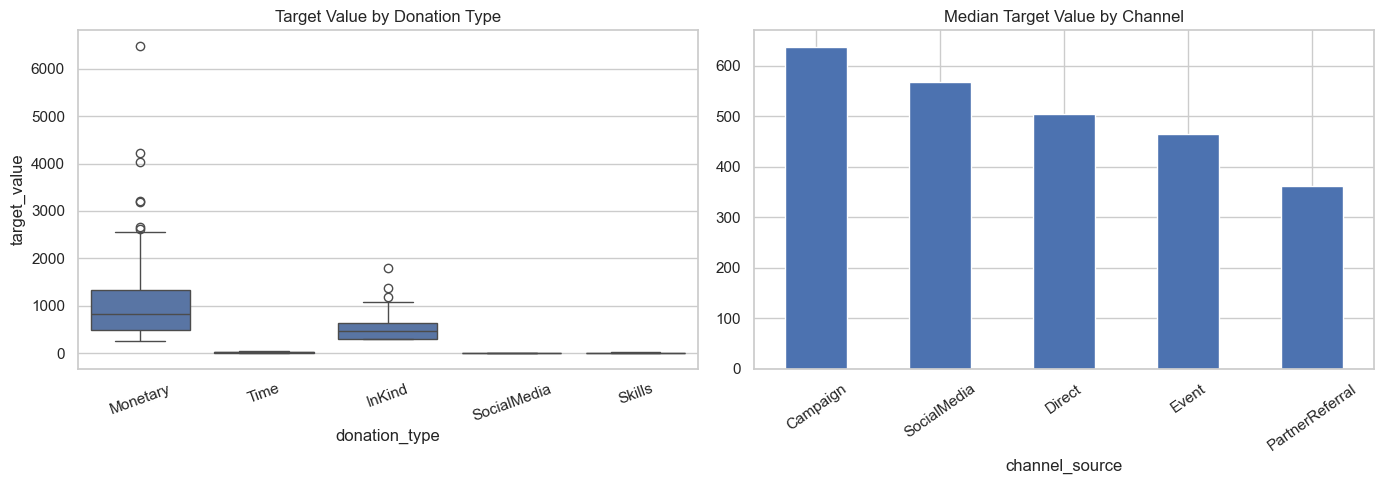

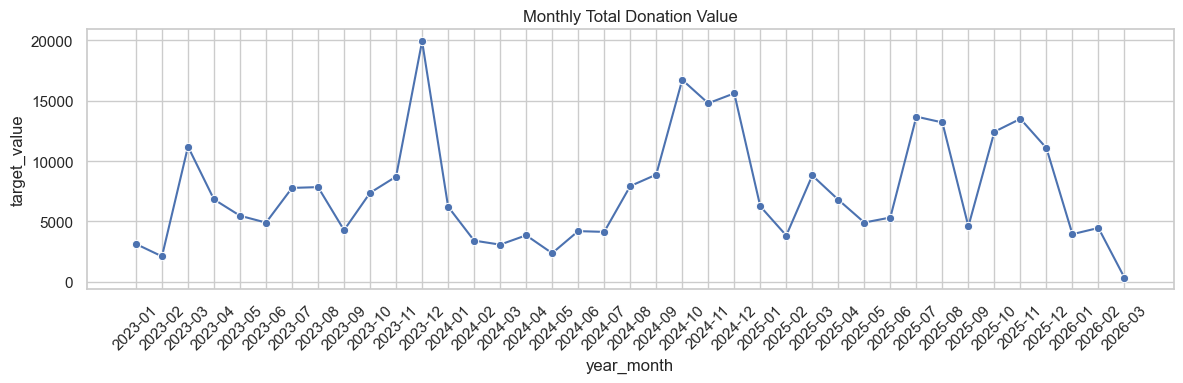

In [4]:
# Chapters 6-8: Univariate and bivariate EDA
eda_df = df.copy()
eda_df["donation_date"] = pd.to_datetime(eda_df["donation_date"], errors="coerce")
eda_df["year_month"] = eda_df["donation_date"].dt.to_period("M").astype(str)

# Resolve a unified numeric value to model and plot
eda_df["target_value"] = eda_df["estimated_value"].fillna(eda_df["amount"])

print("Donation type distribution:")
print(eda_df["donation_type"].value_counts(dropna=False))

print("\nRecurring distribution:")
print(eda_df["is_recurring"].value_counts(dropna=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=eda_df, x="donation_type", y="target_value", ax=axes[0])
axes[0].set_title("Target Value by Donation Type")
axes[0].tick_params(axis="x", rotation=20)

channel_rank = (
    eda_df.groupby("channel_source", dropna=False)["target_value"]
    .median()
    .sort_values(ascending=False)
)
channel_rank.plot(kind="bar", ax=axes[1])
axes[1].set_title("Median Target Value by Channel")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()

monthly = (
    eda_df.groupby("year_month", dropna=False)["target_value"]
    .sum()
    .reset_index()
    .sort_values("year_month")
)

plt.figure(figsize=(12, 4))
sns.lineplot(data=monthly, x="year_month", y="target_value", marker="o")
plt.title("Monthly Total Donation Value")
plt.xticks(rotation=45)
plt.tight_layout()

In [5]:
# Chapters 7, 11: Cleaning rules + train/validation/test split
model_df = df.copy()
model_df["donation_date"] = pd.to_datetime(model_df["donation_date"], errors="coerce")

# Chapter 7 feature engineering
model_df["donation_year"] = model_df["donation_date"].dt.year
model_df["donation_month"] = model_df["donation_date"].dt.month
model_df["donation_dayofweek"] = model_df["donation_date"].dt.dayofweek
model_df["note_length"] = model_df["notes"].fillna("").str.len()
model_df["campaign_name"] = model_df["campaign_name"].fillna("UnknownCampaign")
model_df["channel_source"] = model_df["channel_source"].fillna("UnknownChannel")
model_df["donation_type"] = model_df["donation_type"].fillna("UnknownType")

# Unified regression target
model_df["target_value"] = model_df["estimated_value"].fillna(model_df["amount"])

# Keep rows with known target only
reg_df = model_df.dropna(subset=["target_value"]).copy()

feature_cols = [
    "donation_type",
    "campaign_name",
    "channel_source",
    "currency_code",
    "is_recurring",
    "donation_year",
    "donation_month",
    "donation_dayofweek",
    "note_length",
]

X_reg = reg_df[feature_cols]
y_reg = reg_df["target_value"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Regression train shape: {Xr_train.shape}, test shape: {Xr_test.shape}")

Regression train shape: (336, 9), test shape: (84, 9)


In [6]:
# Chapters 9-12: Regression baselines and tree model
categorical_reg = ["donation_type", "campaign_name", "channel_source", "currency_code", "is_recurring"]
numeric_reg = ["donation_year", "donation_month", "donation_dayofweek", "note_length"]

reg_preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_reg),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_reg),
    ]
)

reg_models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(max_depth=6, random_state=RANDOM_STATE),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=250, random_state=RANDOM_STATE),
}

reg_results = []
for name, model in reg_models.items():
    pipe = Pipeline([
        ("preprocess", reg_preprocess),
        ("model", model),
    ])
    pipe.fit(Xr_train, yr_train)
    preds = pipe.predict(Xr_test)
    rmse = mean_squared_error(yr_test, preds) ** 0.5
    mae = mean_absolute_error(yr_test, preds)
    r2 = r2_score(yr_test, preds)
    reg_results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})

reg_results_df = pd.DataFrame(reg_results).sort_values("rmse")
reg_results_df

,model,rmse,mae,r2
0,LinearRegression,882.812837,487.490437,0.191215
2,RandomForestRegressor,898.856265,495.569600,0.161551
1,DecisionTreeRegressor,1034.140937,551.344953,-0.109828


In [7]:
# Chapters 13-16: Classification (predict recurring donations), ensembles, CV, feature selection
clf_df = model_df.dropna(subset=["is_recurring"]).copy()

X_clf = clf_df[feature_cols]
y_clf = clf_df["is_recurring"].astype(int)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

clf_preprocess = ColumnTransformer(
    transformers=[
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_reg),
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_reg),
    ]
)

clf_models = {
    "LogisticRegression": LogisticRegression(max_iter=1200),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=250, random_state=RANDOM_STATE),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

clf_results = []
for name, model in clf_models.items():
    pipe = Pipeline([
        ("preprocess", clf_preprocess),
        ("model", model),
    ])

    cv_f1 = cross_val_score(pipe, Xc_train, yc_train, cv=5, scoring="f1").mean()
    pipe.fit(Xc_train, yc_train)
    pred = pipe.predict(Xc_test)

    clf_results.append({
        "model": name,
        "accuracy": accuracy_score(yc_test, pred),
        "precision": precision_score(yc_test, pred, zero_division=0),
        "recall": recall_score(yc_test, pred, zero_division=0),
        "f1": f1_score(yc_test, pred, zero_division=0),
        "cv_f1": cv_f1,
    })

clf_results_df = pd.DataFrame(clf_results).sort_values("f1", ascending=False)
clf_results_df

,model,accuracy,precision,recall,f1,cv_f1
0,LogisticRegression,1.0,1.0,1.0,1.0,1.0
1,RandomForestClassifier,1.0,1.0,1.0,1.0,1.0
2,GradientBoostingClassifier,1.0,1.0,1.0,1.0,1.0


In [8]:
# Chapter 15: Hyperparameter tuning example (DecisionTreeRegressor)
dt_pipe = Pipeline([
    ("preprocess", reg_preprocess),
    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

param_grid = {
    "model__max_depth": [3, 5, 7, 9, None],
    "model__min_samples_leaf": [1, 5, 10, 20],
}

grid = GridSearchCV(
    dt_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid.fit(Xr_train, yr_train)

best_dt = grid.best_estimator_
best_dt_pred = best_dt.predict(Xr_test)

print("Best params:", grid.best_params_)
print("Best test RMSE:", round(mean_squared_error(yr_test, best_dt_pred) ** 0.5, 3))
print("Best test MAE:", round(mean_absolute_error(yr_test, best_dt_pred), 3))

Best params: {'model__max_depth': 3, 'model__min_samples_leaf': 10}
Best test RMSE: 841.933
Best test MAE: 454.34


In [9]:
# Chapters 17-18: Save best model + define monitoring baseline
# Select best classifier by test F1
best_clf_name = clf_results_df.iloc[0]["model"]
best_clf_model = clf_models[best_clf_name]

best_clf_pipe = Pipeline([
    ("preprocess", clf_preprocess),
    ("model", best_clf_model),
])
best_clf_pipe.fit(Xc_train, yc_train)

# Persist artifact
artifacts_dir = Path("../artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

try:
    import joblib
    model_path = artifacts_dir / "donations_recurring_model.joblib"
    joblib.dump(best_clf_pipe, model_path)
    print(f"Saved model artifact: {model_path}")
except Exception as e:
    print(f"Could not save model artifact: {e}")

# Monitoring baseline stats
baseline_profile = {
    "train_rows": int(len(Xc_train)),
    "test_rows": int(len(Xc_test)),
    "expected_features": feature_cols,
    "baseline_positive_rate": float(yc_train.mean()),
    "test_positive_rate": float(yc_test.mean()),
    "model": best_clf_name,
    "f1_test": float(clf_results_df.iloc[0]["f1"]),
}

profile_path = artifacts_dir / "donations_monitoring_baseline.json"
with open(profile_path, "w", encoding="utf-8") as f:
    json.dump(baseline_profile, f, indent=2)

baseline_profile

Saved model artifact: ..\artifacts\donations_recurring_model.joblib


{'train_rows': 336,
 'test_rows': 84,
 'expected_features': ['donation_type',
  'campaign_name',
  'channel_source',
  'currency_code',
  'is_recurring',
  'donation_year',
  'donation_month',
  'donation_dayofweek',
  'note_length'],
 'baseline_positive_rate': 0.5029761904761905,
 'test_positive_rate': 0.5,
 'model': 'LogisticRegression',
 'f1_test': 1.0}

In [10]:
# Chapters 19-20: Time trends and clustering
trend_df = model_df.dropna(subset=["donation_date", "target_value"]).copy()
trend_df["year_month"] = trend_df["donation_date"].dt.to_period("M").astype(str)

monthly_metrics = trend_df.groupby("year_month").agg(
    total_value=("target_value", "sum"),
    donation_count=("donation_id", "count"),
    recurring_rate=("is_recurring", "mean"),
).reset_index().sort_values("year_month")

monthly_metrics.tail(12)

# Clustering on donor behavior proxy (event-level features)
cluster_df = trend_df[["target_value", "donation_month", "donation_dayofweek", "note_length"]].copy()
cluster_df = cluster_df.fillna(cluster_df.median(numeric_only=True))

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

sil_scores = {}
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels)

best_k = max(sil_scores, key=sil_scores.get)
best_kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = best_kmeans.fit_predict(X_cluster)

cluster_df["cluster"] = cluster_labels
print("Silhouette by k:", sil_scores)
print("Selected k:", best_k)
cluster_df.groupby("cluster").mean(numeric_only=True)

Silhouette by k: {2: 0.25170432417873234, 3: 0.24756682435150243, 4: 0.25868813957725006, 5: 0.2630432101803153, 6: 0.26440697342263725}
Selected k: 6


,target_value,donation_month,donation_dayofweek,note_length
cluster,,,,
0,2621.500000,9.360000,2.160000,18.720000
1,558.906275,3.529412,5.254902,23.882353
2,514.786316,2.800000,1.694737,17.094737
3,567.330889,9.200000,5.133333,16.200000
4,679.976076,8.443038,2.189873,31.468354
5,574.793750,9.787500,1.487500,16.125000


In [11]:
# Chapters 21-22: Notes text processing and topic extraction
text_df = model_df.copy()
text_df["notes_clean"] = text_df["notes"].fillna("").str.lower().str.replace(r"[^a-z0-9\s]", " ", regex=True)

# TF-IDF representation
vectorizer = TfidfVectorizer(min_df=2, ngram_range=(1, 2), stop_words="english")
X_text = vectorizer.fit_transform(text_df["notes_clean"])

print("TF-IDF shape:", X_text.shape)

# Topic extraction with LDA
n_topics = 4
lda = LatentDirichletAllocation(n_components=n_topics, random_state=RANDOM_STATE)
lda.fit(X_text)

terms = np.array(vectorizer.get_feature_names_out())
for idx, topic in enumerate(lda.components_):
    top_terms = terms[np.argsort(topic)[-8:]][::-1]
    print(f"Topic {idx+1}: {', '.join(top_terms)}")

TF-IDF shape: (420, 20)
Topic 1: donation, event, event donation, support safehouse, safehouse operations, safehouse, operations, support
Topic 2: recurring gift, recurring, gift, support, monthly, contribution, monthly contribution, donation
Topic 3: campaign, campaign support, support, monthly contribution, contribution, monthly, outreach support, outreach
Topic 4: monthly, contribution, monthly contribution, community, community outreach, outreach support, outreach, support


In [12]:
# Chapter 27: Final chapter-aligned output
final_report = {
    "best_regression_model_by_rmse": reg_results_df.iloc[0]["model"],
    "best_classification_model_by_f1": clf_results_df.iloc[0]["model"],
    "best_k_for_clustering": int(best_k),
    "key_actions": [
        "Prioritize channels/campaigns with highest median target_value.",
        "Use recurring prediction model to target likely recurring donors.",
        "Monitor monthly drift in donation_type/channel mix and recurring rate.",
        "Retrain when F1 drops below baseline threshold."
    ],
    "non_applicable_chapters": [
        "Chapter24 (image/OCR)",
        "Chapter25 (collaborative filtering)",
        "Chapter26 (content-based recommender)"
    ]
}

print(json.dumps(final_report, indent=2))

print("\nRegression comparison:")
print(reg_results_df.to_string(index=False))

print("\nClassification comparison:")
print(clf_results_df.to_string(index=False))

{
  "best_regression_model_by_rmse": "LinearRegression",
  "best_classification_model_by_f1": "LogisticRegression",
  "best_k_for_clustering": 6,
  "key_actions": [
    "Prioritize channels/campaigns with highest median target_value.",
    "Use recurring prediction model to target likely recurring donors.",
    "Monitor monthly drift in donation_type/channel mix and recurring rate.",
    "Retrain when F1 drops below baseline threshold."
  ],
  "non_applicable_chapters": [
    "Chapter24 (image/OCR)",
    "Chapter25 (collaborative filtering)",
    "Chapter26 (content-based recommender)"
  ]
}

Regression comparison:
                model        rmse        mae        r2
     LinearRegression  882.812837 487.490437  0.191215
RandomForestRegressor  898.856265 495.569600  0.161551
DecisionTreeRegressor 1034.140937 551.344953 -0.109828

Classification comparison:
                     model  accuracy  precision  recall  f1  cv_f1
        LogisticRegression       1.0        1.0     1.0 1.0   